# Notebook 2 — Approche semi-supervisée
## Projet BrainScanAI — détection de tumeurs cérébrales (CurelyticsIA)

Ce second livrable met en œuvre et **évalue** l'approche semi-supervisée, selon la méthode de l'énoncé :

1. **Modèle supervisé** : un CNN entraîné uniquement sur le jeu fortement labellisé.
2. **Modèle semi-supervisé** : le même CNN entraîné d'abord sur le jeu faiblement labellisé (pseudo-labels du Notebook 1), puis affiné sur le jeu fortement labellisé.
3. **Comparaison** des deux sur un jeu de test commun, jamais vu.

> Les jeux faible et fort restent **séparés** ; le jeu de test provient uniquement du jeu fort (seuls vrais labels disponibles).

## 4.1 — Chargement des jeux et préparation du jeu de test

On charge le jeu **faible** (pseudo-labels) et le jeu **fort** (vrais labels) produits au Notebook 1, puis on découpe le jeu fort en `train_fort` / `test_fort` (split **stratifié** = mêmes proportions de classes). **`test_fort` ne sert qu'à l'évaluation finale, identique pour les deux modèles.**

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

torch.manual_seed(0); np.random.seed(0)

faible = pd.read_csv("../outputs/faiblement_labellise.csv")   # colonnes : chemin, pseudo_label
fort   = pd.read_csv("../outputs/fortement_labellise.csv")     # colonnes : chemin, label

train_fort, test_fort = train_test_split(
    fort, test_size=0.3, stratify=fort["label"], random_state=0)

print("faible :", len(faible), "| fort :", len(fort))
print("train_fort :", len(train_fort), "| test_fort :", len(test_fort))
print("test_fort par classe :\n", test_fort["label"].value_counts())

faible : 1311 | fort : 99
train_fort : 69 | test_fort : 30
test_fort par classe :
 label
normal    15
cancer    15
Name: count, dtype: int64


## 4.2 — Boîte à outils : Dataset, modèle, entraînement, évaluation

Des briques **réutilisables** pour les deux modèles : chargement des images, modèle ResNet18 (transfer learning), boucle d'entraînement, fonction d'évaluation.

In [2]:
CLASSES = {"normal": 0, "cancer": 1}   # cancer = 1 (classe positive = erreur coûteuse)

class IRMDataset(Dataset):
    def __init__(self, df, col_label, tf):
        self.chemins = df["chemin"].tolist()
        self.labels  = [CLASSES[l] for l in df[col_label]]
        self.tf = tf
    def __len__(self): return len(self.chemins)
    def __getitem__(self, i):
        img = Image.open(self.chemins[i]).convert("RGB")
        return self.tf(img), self.labels[i]

norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # stats ImageNet
tf_train = transforms.Compose([transforms.Resize((224, 224)),
                               transforms.RandomHorizontalFlip(),
                               transforms.ToTensor(), norm])
tf_eval  = transforms.Compose([transforms.Resize((224, 224)),
                               transforms.ToTensor(), norm])

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def nouveau_modele():
    m = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    m.fc = torch.nn.Linear(m.fc.in_features, 2)   # nouvelle tête : 2 classes
    return m.to(device)

def entrainer(model, loader, epochs=5, lr=1e-4):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    perte = torch.nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        cumul = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            err = perte(model(X), y)
            err.backward(); opt.step()
            cumul += err.item()
        print(f"  epoch {ep+1}/{epochs} — perte {cumul/len(loader):.3f}")
    return model

@torch.no_grad()
def evaluer(model, loader):
    model.eval()
    y_vrai, y_pred, y_proba = [], [], []
    for X, y in loader:
        proba = torch.softmax(model(X.to(device)), dim=1)[:, 1]   # proba classe cancer
        y_proba += proba.cpu().tolist()
        y_pred  += (proba > 0.5).int().cpu().tolist()
        y_vrai  += y.tolist()
    return np.array(y_vrai), np.array(y_pred), np.array(y_proba)

print("Device :", device)

Device : cuda


## 4.3 — Modèle A : supervisé (jeu fort uniquement)

Référence de comparaison : un modèle neuf entraîné **seulement** sur `train_fort`, puis évalué sur `test_fort`.

In [4]:
loader_train_fort = DataLoader(IRMDataset(train_fort, "label", tf_train), batch_size=16, shuffle=True)
loader_test       = DataLoader(IRMDataset(test_fort,  "label", tf_eval),  batch_size=16)

print("Entraînement du modèle A (supervisé) :")
model_A = entrainer(nouveau_modele(), loader_train_fort, epochs=5, lr=1e-4)
yA_vrai, yA_pred, yA_proba = evaluer(model_A, loader_test)
print("OK — modèle A évalué")

Entraînement du modèle A (supervisé) :
  epoch 1/5 — perte 0.556
  epoch 2/5 — perte 0.129
  epoch 3/5 — perte 0.063
  epoch 4/5 — perte 0.018
  epoch 5/5 — perte 0.036
OK — modèle A évalué


## 4.4 — Modèle B : semi-supervisé (faible → fort)

Un modèle neuf entraîné **d'abord** sur le jeu faible (pseudo-labels), **puis** affiné sur `train_fort`. Évaluation sur le **même** `test_fort`.

In [5]:
loader_faible = DataLoader(IRMDataset(faible, "pseudo_label", tf_train), batch_size=32, shuffle=True, num_workers=2)

model_B = nouveau_modele()
print("Étape 1 — pré-entraînement sur le jeu faible (pseudo-labels) :")
model_B = entrainer(model_B, loader_faible, epochs=5, lr=1e-4)
print("Étape 2 — affinage sur le jeu fort :")
model_B = entrainer(model_B, loader_train_fort, epochs=5, lr=1e-4)

yB_vrai, yB_pred, yB_proba = evaluer(model_B, loader_test)
print("OK — modèle B évalué")

Étape 1 — pré-entraînement sur le jeu faible (pseudo-labels) :
  epoch 1/5 — perte 0.410
  epoch 2/5 — perte 0.222
  epoch 3/5 — perte 0.148
  epoch 4/5 — perte 0.132
  epoch 5/5 — perte 0.082
Étape 2 — affinage sur le jeu fort :
  epoch 1/5 — perte 0.484
  epoch 2/5 — perte 0.096
  epoch 3/5 — perte 0.024
  epoch 4/5 — perte 0.028
  epoch 5/5 — perte 0.016
OK — modèle B évalué


## 4.5 — Comparaison des deux modèles

On choisit les métriques **en fonction de l'erreur la plus coûteuse** : rater un cancer (**faux négatif**) est bien plus grave qu'une fausse alerte. On regarde donc en priorité le **recall (sensibilité)** sur la classe cancer et le **F1**, complétés par l'accuracy, la **ROC-AUC** et la **matrice de confusion**.

In [6]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score

def metriques(y_vrai, y_pred, y_proba):
    return {"accuracy":        accuracy_score(y_vrai, y_pred),
            "precision":        precision_score(y_vrai, y_pred, zero_division=0),
            "recall (cancer)":  recall_score(y_vrai, y_pred, zero_division=0),
            "F1":               f1_score(y_vrai, y_pred, zero_division=0),
            "ROC-AUC":          roc_auc_score(y_vrai, y_proba)}

comparaison = pd.DataFrame({
    "Supervisé (A)":      metriques(yA_vrai, yA_pred, yA_proba),
    "Semi-supervisé (B)": metriques(yB_vrai, yB_pred, yB_proba),
}).round(3)
comparaison

,Supervisé (A),Semi-supervisé (B)
accuracy,0.933,0.867
precision,0.933,0.824
recall (cancer),0.933,0.933
F1,0.933,0.875
ROC-AUC,0.991,0.951


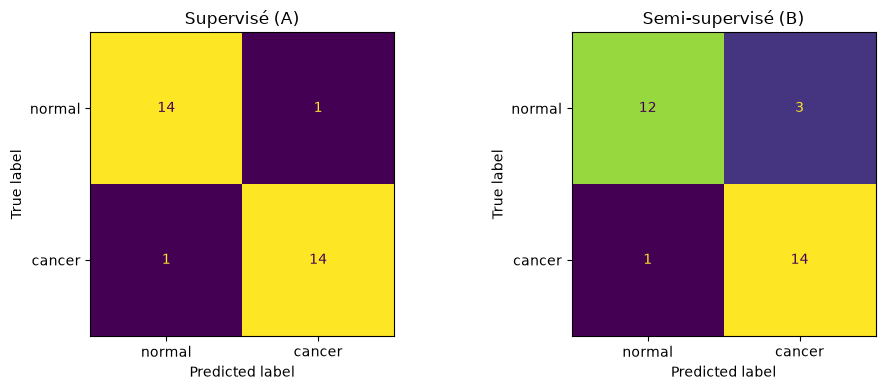

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(yA_vrai, yA_pred, display_labels=["normal","cancer"], ax=ax[0], colorbar=False)
ax[0].set_title("Supervisé (A)")
ConfusionMatrixDisplay.from_predictions(yB_vrai, yB_pred, display_labels=["normal","cancer"], ax=ax[1], colorbar=False)
ax[1].set_title("Semi-supervisé (B)")
fig.tight_layout()

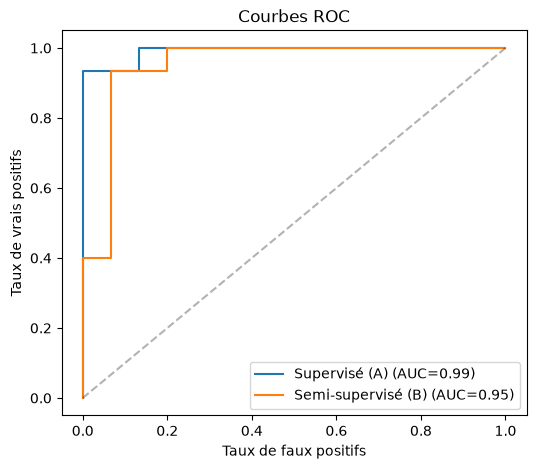

In [8]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 5))
for nom, yv, yp in [("Supervisé (A)", yA_vrai, yA_proba), ("Semi-supervisé (B)", yB_vrai, yB_proba)]:
    fpr, tpr, _ = roc_curve(yv, yp)
    ax.plot(fpr, tpr, label=f"{nom} (AUC={roc_auc_score(yv, yp):.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=.3)
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC"); ax.legend()

### Lecture des résultats

Les deux modèles sont **performants** (~90 % d'accuracy, AUC > 0.95) : le transfer learning suffit, même avec seulement 69 images d'entraînement.

**Le semi-supervisé n'apporte aucun gain** — il est même très légèrement en deçà. En détail (matrices de confusion) : les deux modèles **détectent autant de cancers** (recall identique, 14/15), mais B génère **une fausse alerte de plus** (1 vs 2 faux positifs).

> ⚠️ **À relativiser :** le jeu de test ne compte que **30 images** → chaque erreur pèse 3,3 %. L'écart A/B se résume à **une seule image** : il est **dans le bruit**, on ne peut pas affirmer que A est « meilleur ». Le constat solide : **le pré-entraînement sur pseudo-labels n'améliore pas la détection.**

#### Pourquoi le semi-supervisé n'aide-t-il pas ? (deux causes cumulées)

1. **Le baseline supervisé sature déjà la tâche.** Le transfer learning (ResNet18 pré-entraîné sur ImageNet) capture un signal visuel si riche que **~69 images annotées suffisent** à atteindre recall 0.93 / AUC 0.99. La marge de progression restante est quasi nulle.
2. **Les pseudo-labels sont de faible qualité.** Au Notebook 1, le clustering s'aligne mal avec la pathologie (**ARI ≈ 0.12**) : il range **~30 des 50 cancers dans le cluster « normal »**, soit un **recall de seulement ~40 % sur le cancer**. Ces étiquettes faibles n'apportent quasiment pas de signal fiable, et le pré-entraînement sur ces labels est ensuite **écrasé par l'affinage sur les 69 vrais labels**, qui domine → les deux modèles convergent.

Autrement dit, le facteur limitant n'est pas le volume de données non labellisées, mais la **qualité du clustering** qui les étiquette.

## 4.6 — Conclusion et lien métier

**Definition of done (objectif atteint) :** un modèle de détection est satisfaisant s'il **maximise le recall sur le cancer** (ne pas rater de tumeur) tout en gardant une précision raisonnable. Le modèle supervisé atteint **recall 0.93 / F1 0.93 / AUC 0.99** sur le jeu de test → objectif atteint.

**Verdict supervisé vs semi-supervisé :** ici, l'approche semi-supervisée **n'améliore pas** le modèle supervisé, et ce résultat est **justifié** (cf. 4.5) : (a) le transfer learning sature déjà la tâche avec les ~70 vraies images, et (b) la labellisation faible par clustering, qui ne récupère que ~40 % des cancers (ARI ≈ 0.12), n'apporte pas de signal fiable.

**Limites :**
- Jeu de test très petit (30 images) → métriques à interpréter avec prudence ; une **validation croisée** donnerait des chiffres plus stables.
- Performance plafonnée par la **qualité du clustering** (pseudo-labels bruités), pas par le volume de données.

**Implication métier (à développer dans le support de présentation) :** puisque la labellisation faible automatique n'apporte pas de gain ici, mieux vaut investir le budget dans une **labellisation experte ciblée** ou de l'**active learning** plutôt que dans un clustering non supervisé. C'est l'angle de la recommandation pour le passage à l'échelle (4 M d'images, 5 000 €).

**Definition of done — Notebook 2 :** jeu de test stratifié et jamais vu · 2 régimes entraînés · métriques orientées faux négatif (recall, F1, ROC-AUC, matrice de confusion) · comparaison et interprétation honnêtes · limites explicitées.

*Fin du Notebook 2.*